# TFG V7.1 — Hardware-ready Trotter quantum walk

This version keeps the V7 quantum-walk idea but replaces the dense exact unitary with a Trotterized circuit. It also removes the shortcut of passing precomputed solution indices into the oracle.

## Problem model

The search space is the candidate window-start graph. The grid is prepared as a computational-basis input, and validity is detected reversibly by loading the selected window and checking whether the work register is all zero.

```text
|grid>|idx=i>|work=0> -> |grid>|idx=i>|work=window_i>
```

## Circuit structure

1. Prepare the grid input and a uniform superposition over candidate indices.
2. Apply graph-mixer steps that approximate the walk on the candidate graph.
3. Load the selected window into `work`.
4. Apply a phase only when `work=0...0`.
5. Uncompute `work` and repeat the Trotter step.
6. Measure the index register and score valid-window frequency after measurement.

## Registers and data

- `g`: input grid register.
- `i`: candidate window-start index register.
- `m`: temporary work register containing the selected window.
- `gamma`, `lambda`, `dt`, `steps`: Trotterized quantum-walk parameters.

## Purpose of this version

V7.1 turns the V7 prototype into a circuit path closer to hardware execution. The circuit uses geometry and input-grid data, but it does not receive the solution list as an oracle input.

## Mathematical and Algorithmic Setup

The search space is the set of candidate window starts. The index register stores one start position $i$, the grid register stores the input occupancy bitstring $g$, and the work register temporarily stores the contents of the selected window.

The target continuous-time Hamiltonian is approximated by first-order Trotter steps. For the adjacency convention,

$$H_{\mathrm{adj}}=-\gamma A-\lambda P_V,$$

so one digital step is

$$e^{-iH\Delta t}\approx e^{i\gamma A\Delta t}e^{i\lambda P_V\Delta t}.$$

For the Laplacian convention,

$$H_{\mathrm{lap}}=\gamma(D-A)-\lambda P_V,$$

so the step adds a diagonal degree phase $e^{-i\gamma D\Delta t}$. The important difference from V7 is that $P_V$ is not supplied as a list of valid indices; it is implemented by a reversible validity oracle.


## Requirements and Imports

The notebook uses only standard Qiskit circuit primitives plus NumPy and Matplotlib. Statevector simulation is used only for small demonstrations because the hardware-ready register layout includes the grid and work registers, so the Hilbert space grows with the input grid size.


In [1]:
# pip install qiskit qiskit-aer qiskit-ibm-runtime numpy matplotlib

import os
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(os.getcwd(), ".cache"))
os.environ.setdefault("MPLBACKEND", "Agg")

from math import prod
from pathlib import Path
import ast
import csv
import re
import time

import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCXGate, PhaseGate

try:
    from qiskit_aer import AerSimulator
except Exception:
    AerSimulator = None

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

VALID_COLOR = "#2ecc71"
INVALID_COLOR = "#e74c3c"
BASELINE_COLOR = "0.45"

V7_OUTPUT_DIR = Path("TFG_V7_1_Analysis")
V7_OUTPUT_DIR.mkdir(exist_ok=True)
V7_FIGURE_SUBDIRS = {
    "v7_1_example_circuit_": "circuit_examples",
    "v7_1_gpu_": "gpu_runs",
    "v7_1_trotter_steps_": "trotter_diagnostics",
    "v7_1_resource_growth": "resource_analysis",
}

# V7 uses the earliest time whose success probability is within this
# absolute tolerance of the best scanned peak. This keeps the walk fast
# while preserving a strong success-probability advantage.
V7_PEAK_TOLERANCE = 0.05
# Benchmarked in this environment: 16 qubits is the largest exact
# statevector size that still completes in a tolerable notebook runtime.
V7_1_MAX_STATEVECTOR_QUBITS = 16
V7_1_MAX_SIM_QUBITS = 100
V7_1_DEFAULT_TROTTER_STEPS = 4
V7_1_AER_METHOD = "matrix_product_state"
V7_1_MAX_AER_OPS = 80_000
V7_1_LARGE_CASE_SHOTS = 128
V7_1_LARGE_CASE_OP_THRESHOLD = 25_000

# If True, each case scans only times t <= r_Grover = (pi/4)*sqrt(W/K).
# This forces the quantum-walk search to use no more time/iteration scale
# than the standard Grover estimate for the same valid fraction.
V7_ENFORCE_GROVER_TIME_CAP = False

V7_DEFAULT_T_MAX = 200.0
V7_T_STEPS = 4000

print("qiskit version:", qiskit.__version__)


qiskit version: 2.4.2


## Utility Functions

These are the same geometry utilities used throughout the TFG versions. They define row-major coordinate conversion, candidate window starts, window cell lookup, and the uniform preparation over the physical candidate-index range $0,\ldots,W-1$.


In [2]:

# =========================================================
# ND geometry and classical utilities
# =========================================================

def validate_problem(N, M):
    if len(N) != len(M):
        raise ValueError("N and M must have the same dimension.")
    for d, (n_d, m_d) in enumerate(zip(N, M)):
        if n_d <= 0 or m_d <= 0:
            raise ValueError(f"N[{d}] and M[{d}] must be positive.")
        if m_d > n_d:
            raise ValueError(f"M[{d}] cannot be greater than N[{d}].")


def coord_to_index(coord, dims):
    """Converts ND coordinates to a row-major linear index.
    Example with dims = [4,4]:
    (0,0) -> 0    (0,1) -> 1    (0,2) -> 2    (0,3) -> 3
    (1,0) -> 4    (1,1) -> 5    (1,2) -> 6    (1,3) -> 7
    (2,0) -> 8    (2,1) -> 9    (2,2) -> 10   (2,3) -> 11
    (3,0) -> 12   (3,1) -> 13   (3,2) -> 14   (3,3) -> 15
    Step-by-step example with coord = (1, 2, 0), N = [3, 4, 2]:
    d = 2:
        idx_lin = 0 + 0 * 1 = 0
        stride = 1 * 2 = 2
    d = 1:
        idx_lin = 0 + 2 * 2 = 4
        stride  2 * 4 = 8
    d = 0:
        idx_lin = 4 + 1 * 8 = 12
        stride = 8 * 3 = 24
    result = 12
    """
    idx_lin = 0
    stride = 1
    for d in reversed(range(len(dims))):
        idx_lin += coord[d] * stride
        stride *= dims[d]
    return idx_lin


def index_to_coord(index, dims):
    """Converts a row-major linear index to ND coordinates.
    Example with N = [4,4]:
    0 -> (0,0)    1 -> (0,1)    2 -> (0,2)    3 -> (0,3)
    4 -> (1,0)    5 -> (1,1)    6 -> (1,2)    7 -> (1,3)
    8 -> (2,0)    9 -> (2,1)    10 -> (2,2)   11 -> (2,3)
    12 -> (3,0)   13 -> (3,1)    14 -> (3,2)   15 -> (3,3)
    Step-by-step example with index = 6, N = [4, 4]:
    d = 1:
        coord[1] = 6 % 4 = 2
        rem      = 6 // 4 = 1
    d = 0:
        coord[0] = 1 % 4 = 1
        rem      = 1 // 4 = 0
        result = (1, 2)
    """
    coord = [0] * len(dims)
    rem = index
    for d in reversed(range(len(dims))):
        coord[d] = rem % dims[d]
        rem //= dims[d]
    return tuple(coord)


def valid_starts_nd(N, M):
    """Valid starting coordinates for a window M inside N.
    Example with N = [4, 4] and M = [2, 2]:
        start_shape = [4 - 2 + 1, 4 - 2 + 1] = [3, 3]
        list(np.ndindex((3, 3))) gives:
            (0,0)    (0,1)    (0,2)
            (1,0)    (1,1)    (1,2)
            (2,0)    (2,1)    (2,2)
    """
    return list(np.ndindex(tuple(N[d] - M[d] + 1 for d in range(len(N)))))


def window_qubits_nd(start, N, M):
    """Linear indices of the cells covered by the window starting at start.
    Example with N = [4, 4], M = [2, 2], start = (1, 1):
        offset (0,0) -> coord (1,1) -> index 5
        offset (0,1) -> coord (1,2) -> index 6
        offset (1,0) -> coord (2,1) -> index 9
        offset (1,1) -> coord (2,2) -> index 10
        result = [5, 6, 9, 10]
    """
    qubits = []
    for offset in np.ndindex(tuple(M)):
        coord = tuple(start[d] + offset[d] for d in range(len(N)))
        qubits.append(coord_to_index(coord, N))
    return qubits


def build_grid_bits(N, occupied_coords):
    """Returns a classical vector with 1 on occupied cells and 0 on free cells.
    Function ONLY used for classical prototype.
    Example with N = [4, 4], occupied_coords = [(0,0), (1,2), (3,3)]:
        index  =  0  1  2  3  4  5  6  7  8  9  10 11 12 13 14 15
        result = [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
    """
    grid = [0] * prod(N)
    for coord in occupied_coords:
        grid[coord_to_index(coord, N)] = 1
    return grid


def compute_window_cost_classical(grid_bits, start, N, M):
    """Returns the classical cost C(i) of the window starting at `start`.
    Function ONLY used for classical prototype.
    Example with grid_bits = [1, 0, 0, 0, 1, 0], start = (2,), N = [6], M = [3]:
        result = 1
    """
    return sum(grid_bits[q] for q in window_qubits_nd(start, N, M))


def gray_order_valid(W, IDX):
    """Returns valid indices in Gray-code order, filtered to i < W.
    Example with W = 8, IDX = 3:
        000 -> 0
        001 -> 1
        011 -> 3
        010 -> 2
        110 -> 6
        111 -> 7
        101 -> 5
        100 -> 4
        result = [0, 1, 3, 2, 6, 7, 5, 4]
    """
    gray_full = [t ^ (t >> 1) for t in range(2**IDX)]
    return [g for g in gray_full if g < W]


def format_nd_array_from_bits(bitstring, dims):
    arr = np.array(list(bitstring), dtype=str).reshape(tuple(dims))
    return np.array2string(arr, separator=' ').replace("'", "")


def prepare_valid_index_superposition(qc, idx, W):
    """Prepares a uniform superposition over the valid index states.
    Example with W = 5, IDX = 3:
    The prepared amplitudes for idx are:
            |000> -> 1/sqrt(5)
            |001> -> 1/sqrt(5)
            |010> -> 1/sqrt(5)
            |011> -> 1/sqrt(5)
            |100> -> 1/sqrt(5)
            |101> -> 0
            |110> -> 0
            |111> -> 0
    """   
    IDX = len(idx)
    amps = np.zeros(2**IDX, dtype=complex)
    amps[:W] = 1 / np.sqrt(W)
    qc.initialize(amps, idx)


## Case Studies

20 case studies: five 1D cases, four 2D cases,four 3D cases, four 4D cases and three 5D cases.


In [3]:

CASE_STUDIES = [
    {
        "name": "01_1d_tiny_single_gap",
        "description": "Minimal 1D case with one valid window.",
        "N": [6], "M": [2],
        "occupied_coords": [(0,), (3,), (4,)],
    },
    {
        "name": "02_1d_main_reference",
        "description": "Reference 1D instance used in the manual main experiment.",
        "N": [8], "M": [2],
        "occupied_coords": [(0,), (1,), (2,), (6,), (7,)],
    },
    {
        "name": "03_1d_two_free_regions",
        "description": "1D grid with two occupied blocks and a central valid plateau.",
        "N": [10], "M": [3],
        "occupied_coords": [(0,), (1,), (7,), (8,), (9,)],
    },
    {
        "name": "04_1d_clustered_medium",
        "description": "Medium 1D case with several clustered obstacles.",
        "N": [16], "M": [3],
        "occupied_coords": [(0,), (1,), (5,), (6,), (7,), (13,), (14,)],
    },
    {
        "name": "05_1d_long_clustered_blocks",
        "description": "Longer 1D case with separated occupied blocks.",
        "N": [32], "M": [4],
        "occupied_coords": [(0,), (1,), (2,), (9,), (10,), (11,), (18,), (19,), (28,), (29,), (30,), (31,)],
    },
    {
        "name": "06_2d_tiny_corner_block",
        "description": "Small 2D case with a single valid 2x2 region.",
        "N": [3, 3], "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 2), (2, 2)],
    },
    {
        "name": "07_2d_small_diagonal_block",
        "description": "4x4 grid with diagonal obstacles and one clear lower-left solution.",
        "N": [4, 4], "M": [2, 2],
        "occupied_coords": [(1, 1), (2, 2), (0, 3)],
    },
    {
        "name": "08_2d_medium_clustered_obstacles",
        "description": "5x5 grid with two compact occupied clusters.",
        "N": [5, 5], "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (3, 3), (3, 4), (4, 3)],
    },
    {
        "name": "09_2d_rectangular_window",
        "description": "6x6 grid with a non-square 3x2 window.",
        "N": [6, 6], "M": [3, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (4, 4), (4, 5), (5, 4), (2, 3)],
    },
    {
        "name": "10_3d_small_clustered_obstacles",
        "description": "Small 3D grid with two compact occupied clusters.",
        "N": [4, 4, 3], "M": [2, 2, 2],
        "occupied_coords": [(0, 0, 0), (0, 0, 1), (1, 0, 0), (3, 3, 2), (3, 2, 2), (2, 3, 2)],
    },    {
        "name": "11_3d_dual_room_clusters",
        "description": "3D volume with two compact obstacle rooms and several valid pockets.",
        "N": [5, 5, 4], "M": [2, 2, 2],
        "occupied_coords": [ (0, 0, 0), (0, 0, 1), (1, 0, 0), (1, 1, 0), (3, 3, 2), (3, 3, 3), (4, 3, 2), (4, 4, 3), (2, 1, 1), (2, 2, 1)],
    },
    {
        "name": "12_3d_layered_obstacle_bands",
        "description": "3D layered layout with band-like clustered obstacles across different depths.",
        "N": [6, 5, 4], "M": [2, 2, 2],
        "occupied_coords": [(0, 0, 0), (0, 1, 0), (1, 0, 0), (2, 3, 1), (2, 4, 1), (3, 3, 1), (4, 1, 2), (5, 1, 2), (5, 2, 2), (1, 4, 3), (2, 4, 3)],
    },
    {
        "name": "13_3d_rectangular_window_clusters",
        "description": "3D case with a non-cubic 2x2x3 window and grouped obstacles.",
        "N": [5, 5, 5], "M": [2, 2, 3],
        "occupied_coords": [(0, 0, 0), (0, 1, 0), (1, 0, 0), (2, 2, 2), (2, 3, 2), (3, 2, 2), (4, 4, 4), (4, 3, 4), (3, 4, 4), (1, 3, 1), (1, 3, 2)],
    },
    {
        "name": "14_4d_small_corner_clusters",
        "description": "Small 4D grid with separated clustered obstacles near different corners.",
        "N": [4, 4, 3, 3], "M": [2, 2, 2, 2],
        "occupied_coords": [(0, 0, 0, 0), (0, 1, 0, 0), (1, 0, 0, 0), (3, 3, 2, 2), (3, 2, 2, 2), (2, 3, 2, 2), (1, 2, 1, 1), (2, 1, 1, 1)],
    },
    {
        "name": "15_4d_layered_corridors",
        "description": "4D case with obstacle layers that leave correlated valid hyper-rectangles.",
        "N": [4, 4, 4, 3], "M": [2, 2, 2, 2],
        "occupied_coords": [(0, 0, 0, 0), (0, 1, 0, 0), (1, 0, 0, 0), (2, 2, 2, 1), (2, 3, 2, 1), (3, 2, 2, 1), (1, 3, 1, 2), (2, 3, 1, 2), (3, 0, 3, 2), (3, 1, 3, 2)],
    },
    {
        "name": "16_4d_rectangular_window",
        "description": "4D rectangular-window case with sparse obstacle clusters.",
        "N": [5, 4, 4, 3], "M": [2, 2, 2, 1],
        "occupied_coords": [(0, 0, 0, 0), (1, 0, 0, 0), (3, 2, 2, 1), (3, 3, 2, 1), (4, 2, 2, 1), (2, 1, 3, 2), (2, 2, 3, 2), (4, 3, 0, 2), (4, 3, 1, 2)],
    },
    {
        "name": "17_4d_grouped_islands",
        "description": "Larger 4D candidate graph with several compact obstacle islands.",
        "N": [5, 5, 3, 3], "M": [2, 2, 2, 2],
        "occupied_coords": [(0, 0, 0, 0), (0, 1, 0, 0), (1, 0, 0, 0), (2, 2, 1, 1), (2, 3, 1, 1), (3, 2, 1, 1), (4, 4, 2, 2), (4, 3, 2, 2), (3, 4, 2, 2), (1, 4, 1, 2), (2, 4, 1, 2)],
    },
    {
        "name": "18_5d_tiny_hypercube_clusters",
        "description": "Tiny 5D hypergrid with compact obstacles in opposite hyper-corners.",
        "N": [3, 3, 3, 3, 3], "M": [2, 2, 2, 2, 2],
        "occupied_coords": [(0, 0, 0, 0, 0), (0, 1, 0, 0, 0), (1, 0, 0, 0, 0), (2, 2, 2, 2, 2), (2, 1, 2, 2, 2), (1, 2, 2, 2, 2)],
    },
    {
        "name": "19_5d_layered_sparse_obstacles",
        "description": "5D sparse clustered layout with layered obstacle groups.",
        "N": [4, 3, 3, 3, 3], "M": [2, 2, 2, 2, 2],
        "occupied_coords": [(0, 0, 0, 0, 0), (1, 0, 0, 0, 0), (2, 1, 1, 1, 1), (2, 2, 1, 1, 1), (3, 1, 1, 1, 1), (3, 2, 2, 2, 2), (2, 2, 2, 2, 2), (1, 2, 0, 2, 1)],
    },
    {
        "name": "20_5d_rectangular_hyperwindow",
        "description": "5D rectangular hyperwindow case with several separated obstacle clusters.",
        "N": [4, 4, 3, 3, 3], "M": [2, 2, 2, 1, 2],
        "occupied_coords": [(0, 0, 0, 0, 0), (0, 1, 0, 0, 0), (1, 0, 0, 0, 0), (2, 2, 1, 1, 1), (2, 3, 1, 1, 1), (3, 2, 1, 1, 1), (3, 3, 2, 2, 2), (2, 3, 2, 2, 2), (1, 2, 0, 2, 1), (1, 3, 0, 2, 1)],
    },
]


## Case Context Builder

These helper functions validate each case and build cached per-case contexts so later cells can reuse the same geometry, valid-window information, and summary quantities without recomputing them.


In [4]:
def qw_case_context_hardware(case):
    """Build a hardware-oriented case context with cached reporting data."""
    N_case = list(case["N"])
    M_case = list(case["M"])
    occupied_case = list(case["occupied_coords"])
    validate_problem(N_case, M_case)
    starts_case = valid_starts_nd(N_case, M_case)
    grid_bits_case = build_grid_bits(N_case, occupied_case)
    valid_indices_reporting_only = [
        i for i, start in enumerate(starts_case)
        if compute_window_cost_classical(grid_bits_case, start, N_case, M_case) == 0
    ]
    if not valid_indices_reporting_only:
        raise ValueError(f"Case {case['name']} has no valid windows; change occupied_coords.")
    W_case = len(starts_case)
    IDX_case = int(np.ceil(np.log2(W_case))) if W_case > 1 else 1
    if W_case > 2**IDX_case:
        raise ValueError(f"W={W_case} does not fit in IDX={IDX_case} qubits.")
    grid_qubits_case = prod(N_case)
    work_qubits_case = prod(M_case)
    total_qubits_case = grid_qubits_case + IDX_case + work_qubits_case
    return {
        "name": case["name"],
        "description": case.get("description", ""),
        "N": N_case,
        "M": M_case,
        "occupied_coords": occupied_case,
        "starts": starts_case,
        "grid_bits": grid_bits_case,
        "valid_indices_reporting_only": valid_indices_reporting_only,
        "W": W_case,
        "IDX": IDX_case,
        "GRID": grid_qubits_case,
        "WIN": work_qubits_case,
        "K_reporting_only": len(valid_indices_reporting_only),
        "P_uniform": len(valid_indices_reporting_only) / W_case,
        "TOTAL_QUBITS": total_qubits_case,
    }


CASE_CONTEXTS = [qw_case_context_hardware(case) for case in CASE_STUDIES]
print(f"Loaded {len(CASE_CONTEXTS)} hardware contexts.")
for ctx in CASE_CONTEXTS:
    print(
        f"{ctx['name']} | W={ctx['W']} | total qubits={int(ctx['TOTAL_QUBITS'])} | "
        f"grid qubits={ctx['GRID']} | work qubits={ctx['WIN']} | K(reporting only)={ctx['K_reporting_only']}"
    )



Loaded 20 hardware contexts.
01_1d_tiny_single_gap | W=5 | total qubits=11 | grid qubits=6 | work qubits=2 | K(reporting only)=1
02_1d_main_reference | W=7 | total qubits=13 | grid qubits=8 | work qubits=2 | K(reporting only)=2
03_1d_two_free_regions | W=8 | total qubits=16 | grid qubits=10 | work qubits=3 | K(reporting only)=3
04_1d_clustered_medium | W=14 | total qubits=23 | grid qubits=16 | work qubits=3 | K(reporting only)=4
05_1d_long_clustered_blocks | W=29 | total qubits=41 | grid qubits=32 | work qubits=4 | K(reporting only)=11
06_2d_tiny_corner_block | W=4 | total qubits=15 | grid qubits=9 | work qubits=4 | K(reporting only)=1
07_2d_small_diagonal_block | W=9 | total qubits=24 | grid qubits=16 | work qubits=4 | K(reporting only)=1
08_2d_medium_clustered_obstacles | W=16 | total qubits=33 | grid qubits=25 | work qubits=4 | K(reporting only)=9
09_2d_rectangular_window | W=20 | total qubits=47 | grid qubits=36 | work qubits=6 | K(reporting only)=8
10_3d_small_clustered_obstacles 

## Quantum-Walk Core Functions

These functions build the window-start graph and the quantum-walk operators used in the analysis cells. In TFG_V7.1, they generate the hardware-ready Trotter circuit version: the adjacency convention uses the edge mixer directly, while the Laplacian convention adds the degree-phase layer on top of the same graph structure.


In [5]:
def build_adjacency_matrix(starts, N):
    """Build the symmetric adjacency matrix of the window-start graph.
    Two window starts are adjacent when they differ by exactly one lattice
    step in one coordinate and are equal in all other coordinates.
    The dictionary lookup makes neighbour discovery O(1) per candidate neighbour.
    Example with starts = [(0,0), (0,1), (1,0), (1,1)], N = [2,2]:
        Node indexing:
            0 -> (0,0)
            1 -> (0,1)
            2 -> (1,0)
            3 -> (1,1)
        Graph:
            (0,0) --- (0,1)
              |         |
            (1,0) --- (1,1)
        Adjacency matrix A is:
            A = [[0, 1, 1, 0],
                 [1, 0, 0, 1],
                 [1, 0, 0, 1],
                 [0, 1, 1, 0]]
    Step-by-step example for start = (0,0):
    d = 0:
        step = -1 -> neighbour = (-1,0)
            This does not exist in start_to_index, so it is ignored.

        step = +1 -> neighbour = (1,0)
            This exists with index j = 2.
            Therefore: A[0,2] = 1 and A[2,0] = 1
    d = 1:
        step = -1 -> neighbour = (0,-1)
            This does not exist, so it is ignored.

        step = +1 -> neighbour = (0,1)
            This exists with index j = 1.
            Therefore: A[0,1] = 1 and A[1,0] = 1
    """
    W = len(starts)
    D = len(N)
    start_to_index = {start: i for i, start in enumerate(starts)}
    A = np.zeros((W, W), dtype=np.float64)

    for i, start in enumerate(starts):
        for d in range(D):
            for step in (-1, 1):
                neighbour = list(start)
                neighbour[d] += step
                neighbour = tuple(neighbour)
                j = start_to_index.get(neighbour)
                if j is not None:
                    A[i, j] = 1.0
                    A[j, i] = 1.0
    return A


def build_graph_laplacian(A):
    """Return the unnormalised and normalised graph Laplacians.
    The unnormalised Laplacian is L = D - A, where D is the diagonal degree matrix.
    The normalised Laplacian is D^{-1/2} L D^{-1/2}, removes the dependence on node degree,
        making the dynamics more uniform on irregular graphs.
    Step-by-step example with N = [4, 4], M = [2, 2]:
        2x2 window can start at:
            (0,0)->0 --- (0,1)->1 --- (0,2)->2
              |            |            |
            (1,0)->3 --- (1,1)->4 --- (1,2)->5
              |            |            |
            (2,0)->6 --- (2,1)->7 --- (2,2)->8
        Adjacency matrix A:
            [0, 1, 0, 1, 0, 0, 0, 0, 0]
            [1, 0, 1, 0, 1, 0, 0, 0, 0]
            [0, 1, 0, 0, 0, 1, 0, 0, 0]
            [1, 0, 0, 0, 1, 0, 1, 0, 0]
            [0, 1, 0, 1, 0, 1, 0, 1, 0]
            [0, 0, 1, 0, 1, 0, 0, 0, 1]
            [0, 0, 0, 1, 0, 0, 0, 1, 0]
            [0, 0, 0, 0, 1, 0, 1, 0, 1]
            [0, 0, 0, 0, 0, 1, 0, 1, 0]
        Degrees matrix D:    
            [2, 0, 0, 0, 0, 0, 0, 0, 0]
            [0, 3, 0, 0, 0, 0, 0, 0, 0]
            [0, 0, 2, 0, 0, 0, 0, 0, 0]
            [0, 0, 0, 3, 0, 0, 0, 0, 0]
            [0, 0, 0, 0, 4, 0, 0, 0, 0]
            [0, 0, 0, 0, 0, 3, 0, 0, 0]
            [0, 0, 0, 0, 0, 0, 2, 0, 0]
            [0, 0, 0, 0, 0, 0, 0, 3, 0]
            [0, 0, 0, 0, 0, 0, 0, 0, 2]
        Unnormalised Laplacian L:
            [ 2,-1, 0,-1, 0, 0, 0, 0, 0]
            [-1, 3,-1, 0,-1, 0, 0, 0, 0]
            [ 0,-1, 2, 0, 0,-1, 0, 0, 0]
            [-1, 0, 0, 3,-1, 0,-1, 0, 0]
            [ 0,-1, 0,-1, 4,-1, 0,-1, 0]
            [ 0, 0,-1, 0,-1, 3, 0, 0,-1]
            [ 0, 0, 0,-1, 0, 0, 2,-1, 0]
            [ 0, 0, 0, 0,-1, 0,-1, 3,-1]
            [ 0, 0, 0, 0, 0,-1, 0,-1, 2]
        Inverse degrees matrix D^{-1/2}:
            [1/sqrt(2), 0        , 0        , 0        , 0        , 0        , 0        , 0        , 0        ]
            [0        , 1/sqrt(3), 0        , 0        , 0        , 0        , 0        , 0        , 0        ]
            [0        , 0        , 1/sqrt(2), 0        , 0        , 0        , 0        , 0        , 0        ]
            [0        , 0        , 0        , 1/sqrt(3), 0        , 0        , 0        , 0        , 0        ]
            [0        , 0        , 0        , 0        , 1/sqrt(4), 0        , 0        , 0        , 0        ]
            [0        , 0        , 0        , 0        , 0        , 1/sqrt(3), 0        , 0        , 0        ]
            [0        , 0        , 0        , 0        , 0        , 0        , 1/sqrt(2), 0        , 0        ]
            [0        , 0        , 0        , 0        , 0        , 0        , 0        , 1/sqrt(3), 0        ]
            [0        , 0        , 0        , 0        , 0        , 0        , 0        , 0        , 1/sqrt(2)]            
        Normalised Laplacian L_norm:
            [ 1         ,-1/sqrt(6) ,  0        ,-1/sqrt(6) , 0         , 0         , 0         , 0         , 0         ]
            [-1/sqrt(6) ,  1        ,-1/sqrt(6) , 0         ,-1/sqrt(12), 0         , 0         , 0         , 0         ]
            [ 0         ,-1/sqrt(6) , 1         , 0         , 0         ,-1/sqrt(6) , 0         , 0         , 0         ]
            [-1/sqrt(6) , 0         , 0         , 1         ,-1/sqrt(12), 0         ,-1/sqrt(6) , 0         , 0         ]
            [ 0         ,-1/sqrt(12), 0         ,-1/sqrt(12), 1         ,-1/sqrt(12), 0         ,-1/sqrt(12), 0         ]
            [ 0         , 0         ,-1/sqrt(6) , 0         ,-1/sqrt(12), 1         , 0         , 0         ,-1/sqrt(6) ]
            [ 0         , 0         , 0         ,-1/sqrt(6) , 0         , 0         , 1         ,-1/sqrt(6) , 0         ]
            [ 0         , 0         , 0         , 0         ,-1/sqrt(12), 0         ,-1/sqrt(6) , 1         ,-1/sqrt(6) ]
            [ 0         , 0         , 0         , 0         , 0         ,-1/sqrt(6) , 0         ,-1/sqrt(6) , 1         ]
    """
    A = np.asarray(A, dtype=np.float64)
    D = A @ np.ones(A.shape[0], dtype=np.float64)
    L = np.diag(D) - A
    inv_sqrt_D = np.zeros_like(D)
    nonzero = D > 0
    inv_sqrt_D[nonzero] = 1.0 / np.sqrt(D[nonzero])
    D_inv_sqrt = np.diag(inv_sqrt_D)
    L_norm = D_inv_sqrt @ L @ D_inv_sqrt
    return L, L_norm


def adjacency_edges(A):
    """Return each undirected graph edge once."""
    rows, cols = np.where(np.triu(A, k=1) > 0.5)
    return list(zip(rows.tolist(), cols.tolist()))


def two_level_rotation_matrix(num_qubits, a, b, angle):
    """Return exp(-i angle X_ab) embedded in the index-register space."""
    dim = 2**num_qubits
    U = np.eye(dim, dtype=complex)
    c = np.cos(float(angle))
    s = -1j * np.sin(float(angle))
    U[a, a] = c
    U[b, b] = c
    U[a, b] = s
    U[b, a] = s
    return U


def append_two_level_rotation(qc, idx, a, b, angle, label):
    """Append one local two-level mixer rotation on the index register."""
    from qiskit.circuit.library import UnitaryGate
    U = two_level_rotation_matrix(len(idx), a, b, angle)
    qc.append(UnitaryGate(U, label=label), list(idx))


## Reversible Validity Oracle

This is the main hardware-ready change. The oracle does not know which indices are valid. It computes the window contents for the current superposed index, applies a phase to the all-zero work state, and uncomputes the work register.

The obstacle grid is still the problem input. In this notebook it is prepared as a computational basis state using `X` gates on occupied cells; on real hardware this would be the state-preparation step for the given instance.


In [6]:
def append_mcx(qc, controls, target):
    """Append a multi-controlled X gate using Qiskit's MCXGate primitive."""
    controls = list(controls)
    if len(controls) == 0:
        qc.x(target)
    elif len(controls) == 1:
        qc.cx(controls[0], target)
    else:
        qc.append(MCXGate(num_ctrl_qubits=len(controls)), controls + [target])


def apply_window_loader(qc, grid, idx, window, starts, N, M, W):
    """Load the selected window into work by reversible XOR.

    Implements |g>|i>|m> -> |g>|i>|m xor window_i>. Applying the same block
    twice uncomputes the work register. The loop uses all candidate starts, not
    the valid starts.
    """
    # Number of qubits used to encode the candidate window index.
    IDX = len(idx)
    # Array to keep track of flipped index qubits.
    current_zero_mask = [False] * IDX
    # Shift indices into Gray-code order.
    gray_code_order = [t ^ (t >> 1) for t in range(2**IDX)]
    valid_gray_code_order = [g for g in gray_code_order if g < W]
    # Process each valid candidate window start.
    for i in valid_gray_code_order:
        # Binary representation of i in little-endian order.
        bits = [(i >> b) & 1 for b in range(IDX)]
        # "True" means that idx[b] is 0, so it has to be flipped to 1.
        target_zero_mask = [bits[b] == 0 for b in range(IDX)]
        # Apply X gates and update current indices state, only if required.
        for b in range(IDX):
            if current_zero_mask[b] != target_zero_mask[b]:
                qc.x(idx[b])
                current_zero_mask[b] = target_zero_mask[b]
        # Apply multi-controlled X gates to load the window.
        for j, grid_pos in enumerate(window_qubits_nd(starts[i], N, M)):
            controls = [idx[b] for b in range(IDX)] + [grid[grid_pos]]
            append_mcx(qc, controls, window[j])
    # Flipp all the indices left in 1 back to 0.
    for b in range(IDX):
        if current_zero_mask[b]:
            qc.x(idx[b])


def apply_phase_to_basis_state(qc, register, basis_state, angle, label=None):
    """Apply exp(i angle) to one computational basis state of a register."""
    if abs(float(angle)) < 1e-15:
        return
    qubits = list(register)
    zero_qubits = [q for bit, q in enumerate(qubits) if ((int(basis_state) >> bit) & 1) == 0]
    for q in zero_qubits:
        qc.x(q)
    if len(qubits) == 1:
        qc.p(float(angle), qubits[0])
    else:
        gate = PhaseGate(float(angle), label=label).control(len(qubits) - 1)
        qc.append(gate, qubits[:-1] + [qubits[-1]])
    for q in reversed(zero_qubits):
        qc.x(q)


def apply_defect_oracle_layer(qc, grid, idx, work, ctx, lam, dt, layer):
    """Apply the reversible phase oracle e^{i lambda P_V dt}:
       Load the window, mark work=0...0, and uncompute the load.
    """
    order_valid = gray_order_valid(ctx["W"], ctx["IDX"])
    apply_window_loader(qc, grid, idx, work, ctx["starts"], ctx["N"], ctx["M"], ctx["W"])
    apply_phase_to_basis_state(qc, work, 0, float(lam) * float(dt), label=f"valid-phase[{layer}]")
    apply_window_loader(qc, grid, idx, work, ctx["starts"], ctx["N"], ctx["M"], ctx["W"])


## Hardware-Ready Quantum Walk Circuit Construction

This section turns the case context and quantum-walk operators into the circuit used by the later analysis cells. In TFG_V7.1, the construction is hardware-ready and uses three registers: `g` for the input grid, `i` for the candidate window-start index, and `m` for the temporary work register loaded by the oracle.

No dense exact Hamiltonian is constructed. No precomputed `valid_indices` list is passed into the circuit. The only classical information compiled into the oracle is the grid geometry and the input bitstring.


In [7]:
def apply_degree_phase_layer(qc, idx, degrees, gamma, dt, layer):
    """Apply the Laplacian degree phase exp(-i gamma D dt)."""
    # Each state |i> accumulates a phase proportional to node degree i.
    for i, degree in enumerate(degrees):
        apply_phase_to_basis_state(qc, idx, i, -float(gamma) * float(degree) * float(dt), label=f"deg[{layer},{i}]")


def apply_edge_mixer_layer(qc, idx, edges, gamma, dt, layer):
    """Apply first-order edge rotations for exp(+i gamma A dt)."""
    # Since the primitive is exp(-i angle X_ab), use angle=-gamma*dt.
    for edge_id, (a, b) in enumerate(edges):
        append_two_level_rotation(qc, idx, a, b, -float(gamma) * float(dt), label=f"mix[{layer},{edge_id}]")


def build_quantum_walk_circuit(ctx, lam, t_total, r_trotter=4, gamma=1.0, mode="adjacency"):
    """Build a Trotterised CTQW circuit without valid_indices or exact exp(-iHt).
       The circuit evaluates validity with a reversible oracle in every layer.
    """
    mode = str(mode).lower()
    if mode not in {"adjacency", "laplacian"}:
        raise ValueError("mode must be 'adjacency' or 'laplacian'.")
    r_trotter = int(r_trotter)
    if r_trotter <= 0:
        raise ValueError("r_trotter must be positive.")
    dt = float(t_total) / r_trotter

    grid = QuantumRegister(ctx["GRID"], "g")
    idx = QuantumRegister(ctx["IDX"], "i")
    work = QuantumRegister(ctx["WIN"], "m")
    qc = QuantumCircuit(grid, idx, work)

    for q, bit in zip(grid, ctx["grid_bits"]):
        if bit:
            qc.x(q)
    prepare_valid_index_superposition(qc, idx, ctx["W"])

    A = build_adjacency_matrix(ctx["starts"], ctx["N"])
    edges = adjacency_edges(A)
    degrees = A @ np.ones(ctx["W"], dtype=np.float64)
    
    # qc.barrier(label=f"Preparation layer complete")
    for layer in range(r_trotter):
        if mode == "laplacian":
            apply_degree_phase_layer(qc, idx, degrees, gamma, dt, layer)
        apply_edge_mixer_layer(qc, idx, edges, gamma, dt, layer)
        apply_defect_oracle_layer(qc, grid, idx, work, ctx, lam, dt, layer)
        # qc.barrier(label=f"Trotter {layer + 1}/{r_trotter}")

    metadata = {
        "mode": mode,
        "lam": float(lam),
        "gamma": float(gamma),
        "t_total": float(t_total),
        "r_trotter": r_trotter,
        "dt": dt,
        "edges": edges,
        "degrees": degrees,
        "qubits": qc.num_qubits,
        "operations": dict(qc.count_ops()),
    }
    return qc, metadata


def marginal_index_probabilities(sv, qc, idx_register, W):
    """Return marginal probabilities over the physical index states 0..W-1."""
    # Qiskit marginalizes over idx qubits even when grid and work are present.
    qargs = [qc.qubits.index(q) for q in idx_register]
    probs_full = np.asarray(sv.probabilities(qargs=qargs), dtype=float)
    return probs_full[:W]


def simulate_hardware_qw_case(ctx, lam=None, t_total=None, r_trotter=V7_1_DEFAULT_TROTTER_STEPS, gamma=1.0, mode="adjacency"):
    """Build and simulate one small hardware-layout QW case."""
    # Simulation is limited to small cases because it includes grid+idx+work.
    solution_for_report = list(ctx["valid_indices_reporting_only"])
    if lam is None:
        lam = np.sqrt(ctx["W"]) * float(gamma)
    if t_total is None:
        t_total = np.pi / 4.0 * np.sqrt(ctx["W"] / len(solution_for_report))

    qc, metadata = build_quantum_walk_circuit(
        ctx, lam=lam, t_total=t_total, r_trotter=r_trotter, gamma=gamma, mode=mode
    )
    if qc.num_qubits > V7_1_MAX_STATEVECTOR_QUBITS:
        raise ValueError(f"Circuit has {qc.num_qubits} qubits; statevector cap is {V7_1_MAX_STATEVECTOR_QUBITS}.")

    sv = Statevector.from_instruction(qc)
    idx_reg = qc.qregs[1]
    probs = marginal_index_probabilities(sv, qc, idx_reg, ctx["W"])
    p_valid = float(np.sum(probs[solution_for_report]))
    return {
        "case": ctx["name"],
        "ctx": ctx,
        "qc": qc,
        "metadata": metadata,
        "solution_indices_reporting_only": solution_for_report,
        "probs": probs,
        "P_valid": p_valid,
        "P_uniform": float(ctx["P_uniform"]),
    }


## Plotting Utilities for the Analysis Cells

These helper functions keep the analysis cells short while ensuring consistent colours, labels, figure sizes, and saved outputs.


In [8]:
def qw_slug(text):
    """Return a filesystem-safe lowercase slug for figure filenames."""
    return re.sub(r"[^a-zA-Z0-9_]+", "_", str(text)).strip("_").lower()


def figure_output_dir(stem):
    """Return the output folder for one figure stem."""
    for prefix, subdir in V7_FIGURE_SUBDIRS.items():
        if stem.startswith(prefix):
            out_dir = V7_OUTPUT_DIR / subdir
            out_dir.mkdir(parents=True, exist_ok=True)
            return out_dir
    V7_OUTPUT_DIR.mkdir(exist_ok=True)
    return V7_OUTPUT_DIR


def save_figure(fig, stem):
    """Save a Matplotlib figure as PDF and PNG in the V7.1 analysis folder."""
    out_dir = figure_output_dir(stem)
    # fig.savefig(out_dir / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{stem}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)


## Demonstration Runs

This section starts with one readable example circuit and then moves to the small-case reference simulations used throughout the later comparisons.


Example case: 01_1d_tiny_single_gap
Qubits: 11
Operations: {'x': 27, 'mcx': 20, 'unitary': 4, 'initialize': 1, 'cp': 1}


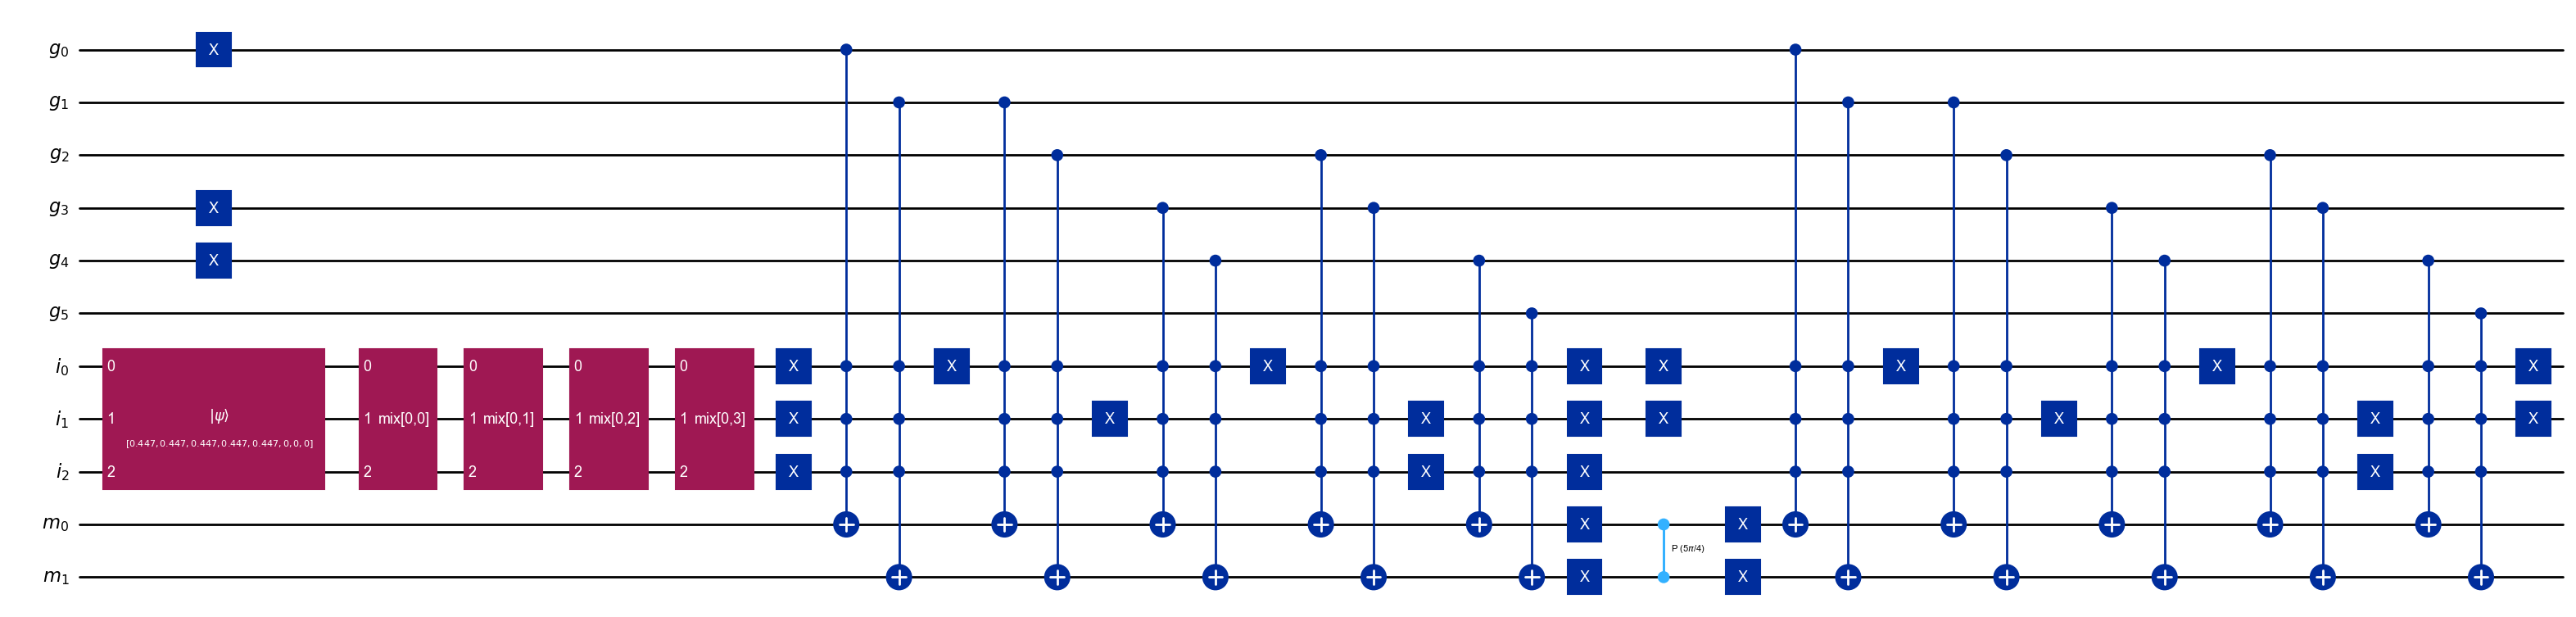

In [9]:
# =========================================================
# Draw example trotterised CTQW circuit
# =========================================================

# Choose a small case so the circuit drawing is readable.
# Case 01 is a good option because it has few grid/work/index qubits.
example_ctx = CASE_CONTEXTS[0]

# Build a small trotterised circuit.
# r_trotter=1 is best for the figure because it shows one full CTQW step:
# graph-walk layer + defect-oracle layer.
example_qc, example_metadata = build_quantum_walk_circuit(
    example_ctx,
    lam=np.sqrt(example_ctx["W"]),
    t_total=np.pi / 4.0 * np.sqrt(example_ctx["W"]),
    r_trotter=1,
    gamma=1.0,
    mode="adjacency",
)

print("Example case:", example_ctx["name"])
print("Qubits:", example_qc.num_qubits)
print("Operations:", example_metadata["operations"])

example_fig = example_qc.draw(output="mpl", fold=-1)
save_figure(example_fig, f"v7_1_example_circuit_{qw_slug(example_ctx['name'])}")
example_fig



## Small-Case Simulation and Scoring

These cells run the small hardware-ready examples that still fit the chosen simulator caps, then compare their observed success probability against the uniform baseline.


In [10]:
SIM_RESULTS = []
for ctx in CASE_CONTEXTS:
    total_qubits = int(ctx["TOTAL_QUBITS"])
    if total_qubits > V7_1_MAX_STATEVECTOR_QUBITS:
        print(f"skip statevector reference: {ctx['name']} has {total_qubits} qubits")
        continue
    for mode in ["adjacency", "laplacian"]:
        result = simulate_hardware_qw_case(ctx, mode=mode)
        SIM_RESULTS.append(result)
        print(
            f"{ctx['name']} | mode={mode} | qubits={result['qc'].num_qubits} | "
            f"P_uniform={result['P_uniform']:.4f} | P_valid(statevector)={result['P_valid']:.4f} | "
            f"ops={result['metadata']['operations']}"
        )



01_1d_tiny_single_gap | mode=adjacency | qubits=11 | P_uniform=0.2000 | P_valid(statevector)=0.5325 | ops={'x': 99, 'mcx': 80, 'unitary': 16, 'cp': 4, 'initialize': 1}
01_1d_tiny_single_gap | mode=laplacian | qubits=11 | P_uniform=0.2000 | P_valid(statevector)=0.5597 | ops={'x': 179, 'mcx': 80, 'mcphase': 20, 'unitary': 16, 'cp': 4, 'initialize': 1}
02_1d_main_reference | mode=adjacency | qubits=13 | P_uniform=0.2857 | P_valid(statevector)=0.5668 | ops={'x': 117, 'mcx': 112, 'unitary': 24, 'cp': 4, 'initialize': 1}
02_1d_main_reference | mode=laplacian | qubits=13 | P_uniform=0.2857 | P_valid(statevector)=0.4923 | ops={'x': 213, 'mcx': 112, 'mcphase': 28, 'unitary': 24, 'cp': 4, 'initialize': 1}
03_1d_two_free_regions | mode=adjacency | qubits=16 | P_uniform=0.3750 | P_valid(statevector)=0.6738 | ops={'mcx': 192, 'x': 125, 'unitary': 28, 'mcphase': 4, 'initialize': 1}
03_1d_two_free_regions | mode=laplacian | qubits=16 | P_uniform=0.3750 | P_valid(statevector)=0.6065 | ops={'x': 221, '

## Hardware-Ready Comparison Graph

This graph compares the simulated success probability for all small cases that fit in the statevector cap. The probability baseline is still classical reporting, but the circuit execution path uses only the reversible oracle.


In [11]:
if SIM_RESULTS:
    cases = sorted({res["case"] for res in SIM_RESULTS})
    x = np.arange(len(cases))
    width = 0.25
    adj = {res["case"]: res for res in SIM_RESULTS if res["metadata"]["mode"] == "adjacency"}
    lap = {res["case"]: res for res in SIM_RESULTS if res["metadata"]["mode"] == "laplacian"}
    uniform_vals = np.array([adj.get(c, lap.get(c))["P_uniform"] for c in cases])
    adj_vals = np.array([adj[c]["P_valid"] if c in adj else np.nan for c in cases])
    lap_vals = np.array([lap[c]["P_valid"] if c in lap else np.nan for c in cases])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, uniform_vals, width=width, color=BASELINE_COLOR, alpha=0.75, label="uniform")
    ax.bar(x, adj_vals, width=width, color=VALID_COLOR, alpha=0.9, label="adjacency Trotter")
    ax.bar(x + width, lap_vals, width=width, color="#3498db", alpha=0.85, label="laplacian Trotter")
    ax.set_xticks(x)
    ax.set_xticklabels([c.split("_", 1)[0] for c in cases])
    ax.set_xlabel("case")
    ax.set_ylabel("P_valid")
    ax.set_title("V7.1 hardware-ready Trotter QW: small-case simulation")
    ax.legend(fontsize=10)
    fig.tight_layout()
    save_figure(fig, "v7_1_probability_comparison")
else:
    print("No cases fit the current statevector simulation cap.")


## Shot-Based Measurement of the Index Register

The previous section uses an ideal statevector to read exact probabilities. This section follows the experimental workflow more closely: it measures the `idx` register, obtains finite-shot counts, and estimates the valid-window success probability as an observed frequency.

The solution indices are still computed classically only after measurement, for scoring the bitstrings. They are not used to build the circuit or the validity oracle.


In [12]:
V7_1_SHOTS = 4096
V7_1_SHOT_SEED = 12345


def add_index_measurements(qc):
    """Return a copy of qc with measurements on the index register only."""
    # Measure only idx because the algorithm returns a window index.
    measured = qc.copy()
    idx_reg = measured.qregs[1]
    c_idx = ClassicalRegister(len(idx_reg), "c_i")
    measured.add_register(c_idx)
    measured.measure(idx_reg, c_idx)
    return measured


def count_key_to_index(bitstring):
    """Convert a Qiskit count key for c_i into the measured integer index."""
    # Qiskit displays classical bits in big-endian order; int(..., 2) recovers c_i as an integer.
    compact = str(bitstring).replace(" ", "")
    return int(compact, 2)


def build_shot_qw_case(ctx, lam=None, t_total=None, r_trotter=V7_1_DEFAULT_TROTTER_STEPS, gamma=1.0, mode="adjacency"):
    """Build one hardware-layout circuit for finite-shot execution."""
    # This path does not compute a statevector; it only builds the measurable circuit.
    solution_for_report = list(ctx["valid_indices_reporting_only"])
    if lam is None:
        lam = np.sqrt(ctx["W"]) * float(gamma)
    if t_total is None:
        t_total = np.pi / 4.0 * np.sqrt(ctx["W"] / len(solution_for_report))
    qc, metadata = build_quantum_walk_circuit(
        ctx, lam=lam, t_total=t_total, r_trotter=r_trotter, gamma=gamma, mode=mode
    )
    if qc.num_qubits > V7_1_MAX_SIM_QUBITS:
        raise ValueError(f"Circuit has {qc.num_qubits} qubits; shot-simulation cap is {V7_1_MAX_SIM_QUBITS}.")
    return {
        "case": ctx["name"],
        "ctx": ctx,
        "qc": qc,
        "metadata": metadata,
        "solution_indices_reporting_only": solution_for_report,
        "P_uniform": float(ctx["P_uniform"]),
        "P_valid": np.nan,
        "op_count": int(sum(qc.count_ops().values())),
    }


def run_idx_shots(result, shots=V7_1_SHOTS, seed=V7_1_SHOT_SEED):
    """Measure idx with finite shots and estimate P_valid from observed counts."""
    # The solution set is used only to score samples after they are obtained.
    measured_qc = add_index_measurements(result["qc"])
    W = result["ctx"]["W"]
    IDX = result["ctx"]["IDX"]

    if AerSimulator is not None:
        simulator = AerSimulator(method="statevector", seed_simulator=int(seed))
        counts = simulator.run(measured_qc, shots=int(shots)).result().get_counts()
        backend_label = "AerSimulator(statevector)"
    else:
        if "probs" not in result:
            raise ImportError("qiskit-aer is required for shot simulation above the statevector cap.")
        # Reproducible fallback when qiskit-aer is not installed in the kernel.
        rng = np.random.default_rng(int(seed))
        physical_probs = np.asarray(result["probs"], dtype=float)
        physical_probs = physical_probs / np.sum(physical_probs)
        sampled_counts = rng.multinomial(int(shots), physical_probs)
        counts = {format(i, f"0{IDX}b"): int(c) for i, c in enumerate(sampled_counts) if c}
        backend_label = "statevector multinomial sampler (Aer unavailable)"

    solution = set(result["solution_indices_reporting_only"])
    valid_count = 0
    physical_count = 0
    index_counts = {i: 0 for i in range(W)}
    padded_count = 0

    for key, count in counts.items():
        idx_value = count_key_to_index(key)
        if idx_value < W:
            physical_count += int(count)
            index_counts[idx_value] += int(count)
            if idx_value in solution:
                valid_count += int(count)
        else:
            padded_count += int(count)

    p_valid_shots = valid_count / float(shots)
    stderr = np.sqrt(max(p_valid_shots * (1.0 - p_valid_shots), 0.0) / float(shots))
    return {
        "case": result["case"],
        "mode": result["metadata"]["mode"],
        "qubits": int(result["qc"].num_qubits),
        "op_count": int(result.get("op_count", sum(result["qc"].count_ops().values()))),
        "shots": int(shots),
        "backend": backend_label,
        "measured_qc": measured_qc,
        "counts": counts,
        "index_counts": index_counts,
        "valid_count": int(valid_count),
        "physical_count": int(physical_count),
        "padded_count": int(padded_count),
        "P_valid_shots": float(p_valid_shots),
        "P_valid_statevector": float(result.get("P_valid", np.nan)),
        "P_uniform": float(result["P_uniform"]),
        "stderr": float(stderr),
    }


SHOT_RESULTS = []
SHOT_SKIPPED = []
STATEVECTOR_LOOKUP = {
    (res["case"], res["metadata"]["mode"]): res["P_valid"]
    for res in SIM_RESULTS
}

for ctx in CASE_CONTEXTS:
    total_qubits = int(ctx["TOTAL_QUBITS"])
    if total_qubits > V7_1_MAX_SIM_QUBITS:
        reason = f"qubits {total_qubits} > cap {V7_1_MAX_SIM_QUBITS}"
        print(f"skip shot simulation: {ctx['name']} | {reason}")
        SHOT_SKIPPED.append({"case": ctx["name"], "mode": "both", "qubits": total_qubits, "op_count": np.nan, "reason": reason})
        continue
    for mode in ["adjacency", "laplacian"]:
        shot_input = build_shot_qw_case(ctx, mode=mode)
        op_count = int(shot_input["op_count"])
        if shot_input["qc"].num_qubits > V7_1_MAX_STATEVECTOR_QUBITS:
            reason = f"exact statevector shots limited to {V7_1_MAX_STATEVECTOR_QUBITS} qubits; case has {shot_input['qc'].num_qubits}"
            print(f"skip shot simulation: {ctx['name']} | mode={mode} | qubits={shot_input['qc'].num_qubits} | {reason}")
            SHOT_SKIPPED.append({"case": ctx["name"], "mode": mode, "qubits": shot_input["qc"].num_qubits, "op_count": op_count, "reason": reason})
            continue
        if op_count > V7_1_MAX_AER_OPS:
            reason = f"ops {op_count} > cap {V7_1_MAX_AER_OPS}"
            print(f"skip shot simulation: {ctx['name']} | mode={mode} | qubits={shot_input['qc'].num_qubits} | {reason}")
            SHOT_SKIPPED.append({"case": ctx["name"], "mode": mode, "qubits": shot_input["qc"].num_qubits, "op_count": op_count, "reason": reason})
            continue
        shot_input["P_valid"] = STATEVECTOR_LOOKUP.get((ctx["name"], mode), np.nan)
        active_shots = V7_1_SHOTS
        try:
            shot_result = run_idx_shots(shot_input, shots=active_shots)
        except Exception as exc:
            reason = f"{type(exc).__name__}: {exc}"
            print(f"shot simulation failed: {ctx['name']} | mode={mode} | qubits={shot_input['qc'].num_qubits} | ops={op_count} | {reason}")
            SHOT_SKIPPED.append({"case": ctx["name"], "mode": mode, "qubits": shot_input["qc"].num_qubits, "op_count": op_count, "reason": reason})
            continue
        SHOT_RESULTS.append(shot_result)
        statevector_text = "n/a" if np.isnan(shot_result["P_valid_statevector"]) else f"{shot_result['P_valid_statevector']:.4f}"
        print(
            f"{shot_result['case']} | mode={shot_result['mode']} | qubits={shot_result['qubits']} | ops={shot_result['op_count']} | shots={shot_result['shots']} | "
            f"valid counts={shot_result['valid_count']} | P_valid(shots)={shot_result['P_valid_shots']:.4f} ± {shot_result['stderr']:.4f} | "
            f"statevector={statevector_text} | padded={shot_result['padded_count']} | backend={shot_result['backend']}"
        )

csv_path = V7_OUTPUT_DIR / "v7_1_shot_results.csv"
shot_headers = [
    "case", "mode", "qubits", "op_count", "shots", "backend", "valid_count", "physical_count", "padded_count",
    "P_uniform", "P_valid_shots", "stderr", "P_valid_statevector",
]
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=shot_headers)
    writer.writeheader()
    for row in SHOT_RESULTS:
        writer.writerow({key: row[key] for key in shot_headers})
print(f"Saved {csv_path}")

skipped_path = V7_OUTPUT_DIR / "v7_1_shot_skipped.csv"
skipped_headers = ["case", "mode", "qubits", "op_count", "reason"]
with skipped_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=skipped_headers)
    writer.writeheader()
    writer.writerows(SHOT_SKIPPED)
print(f"Saved {skipped_path}")



01_1d_tiny_single_gap | mode=adjacency | qubits=11 | ops=200 | shots=4096 | valid counts=2201 | P_valid(shots)=0.5374 ± 0.0078 | statevector=0.5325 | padded=0 | backend=AerSimulator(statevector)
01_1d_tiny_single_gap | mode=laplacian | qubits=11 | ops=300 | shots=4096 | valid counts=2284 | P_valid(shots)=0.5576 ± 0.0078 | statevector=0.5597 | padded=0 | backend=AerSimulator(statevector)
02_1d_main_reference | mode=adjacency | qubits=13 | ops=258 | shots=4096 | valid counts=2334 | P_valid(shots)=0.5698 ± 0.0077 | statevector=0.5668 | padded=0 | backend=AerSimulator(statevector)
02_1d_main_reference | mode=laplacian | qubits=13 | ops=382 | shots=4096 | valid counts=2065 | P_valid(shots)=0.5042 ± 0.0078 | statevector=0.4923 | padded=0 | backend=AerSimulator(statevector)
03_1d_two_free_regions | mode=adjacency | qubits=16 | ops=350 | shots=4096 | valid counts=2745 | P_valid(shots)=0.6702 ± 0.0073 | statevector=0.6738 | padded=0 | backend=AerSimulator(statevector)
03_1d_two_free_regions | m

## Shot-Based Probability Comparison

This figure uses the finite-shot frequencies from the previous cell. Error bars show one binomial standard error, so repeated runs with different random seeds will fluctuate around the statevector reference.


In [13]:
if SHOT_RESULTS:
    print("Shot results saved to CSV. No separate shot probability plot is generated because it duplicates the main probability comparison figure.")
else:
    print("No shot results available.")


Shot results saved to CSV. No separate shot probability plot is generated because it duplicates the main probability comparison figure.


## Resource Estimate for All Cases

This cell builds circuits for every case and reports qubit counts and operation counts. It does not simulate large statevectors. This is the practical view needed before transpilation to a specific backend.


In [14]:
RESOURCE_ROWS = []
for ctx in CASE_CONTEXTS:
    for mode in ["adjacency", "laplacian"]:
        solution_for_report = list(ctx["valid_indices_reporting_only"])
        lam = np.sqrt(ctx["W"])
        t_total = np.pi / 4.0 * np.sqrt(ctx["W"] / len(solution_for_report))
        qc, meta = build_quantum_walk_circuit(ctx, lam=lam, t_total=t_total, r_trotter=V7_1_DEFAULT_TROTTER_STEPS, mode=mode)
        row = {
            "case": ctx["name"],
            "mode": mode,
            "W": ctx["W"],
            "K_reporting_only": ctx["K_reporting_only"],
            "grid_qubits": ctx["GRID"],
            "idx_qubits": ctx["IDX"],
            "work_qubits": ctx["WIN"],
            "total_qubits": int(ctx["TOTAL_QUBITS"]),
            "r_trotter": V7_1_DEFAULT_TROTTER_STEPS,
            "operations": str(meta["operations"]),
        }
        RESOURCE_ROWS.append(row)
        print(row)

csv_path = V7_OUTPUT_DIR / "v7_1_hardware_resources.csv"
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(RESOURCE_ROWS[0].keys()))
    writer.writeheader()
    writer.writerows(RESOURCE_ROWS)
print(f"Saved {csv_path}")



{'case': '01_1d_tiny_single_gap', 'mode': 'adjacency', 'W': 5, 'K_reporting_only': 1, 'grid_qubits': 6, 'idx_qubits': 3, 'work_qubits': 2, 'total_qubits': 11, 'r_trotter': 4, 'operations': "{'x': 99, 'mcx': 80, 'unitary': 16, 'cp': 4, 'initialize': 1}"}
{'case': '01_1d_tiny_single_gap', 'mode': 'laplacian', 'W': 5, 'K_reporting_only': 1, 'grid_qubits': 6, 'idx_qubits': 3, 'work_qubits': 2, 'total_qubits': 11, 'r_trotter': 4, 'operations': "{'x': 179, 'mcx': 80, 'mcphase': 20, 'unitary': 16, 'cp': 4, 'initialize': 1}"}
{'case': '02_1d_main_reference', 'mode': 'adjacency', 'W': 7, 'K_reporting_only': 2, 'grid_qubits': 8, 'idx_qubits': 3, 'work_qubits': 2, 'total_qubits': 13, 'r_trotter': 4, 'operations': "{'x': 117, 'mcx': 112, 'unitary': 24, 'cp': 4, 'initialize': 1}"}
{'case': '02_1d_main_reference', 'mode': 'laplacian', 'W': 7, 'K_reporting_only': 2, 'grid_qubits': 8, 'idx_qubits': 3, 'work_qubits': 2, 'total_qubits': 13, 'r_trotter': 4, 'operations': "{'x': 213, 'mcx': 112, 'mcphase'

## Effect of the Number of Trotter Steps

This section varies the Trotter step count on one reference case to show the trade-off between success probability and circuit size.


In [15]:
# =========================================================
# Effect of the number of Trotter steps
# =========================================================

# Average over several small cases so the trend reflects more than one layout.
trotter_case_names = [
    "01_1d_tiny_single_gap",
    "02_1d_main_reference",
    "03_1d_two_free_regions",
    "06_2d_tiny_corner_block",
]
trotter_contexts = [ctx for ctx in CASE_CONTEXTS if ctx["name"] in trotter_case_names]

r_values = [1, 2, 3, 4, 6, 8]
rows = []

for r in r_values:
    case_results = []
    for trotter_ctx in trotter_contexts:
        solution_for_report = list(trotter_ctx["valid_indices_reporting_only"])
        lam = np.sqrt(trotter_ctx["W"])
        t_total = np.pi / 4.0 * np.sqrt(trotter_ctx["W"] / len(solution_for_report))
        result = simulate_hardware_qw_case(
            trotter_ctx,
            lam=lam,
            t_total=t_total,
            r_trotter=r,
            gamma=1.0,
            mode="adjacency",
        )
        case_results.append({
            "P_valid": result["P_valid"],
            "P_uniform": trotter_ctx["P_uniform"],
            "op_count": int(sum(result["qc"].count_ops().values())),
        })

    rows.append({
        "r_trotter": r,
        "P_valid_mean": float(np.mean([row["P_valid"] for row in case_results])),
        "P_uniform_mean": float(np.mean([row["P_uniform"] for row in case_results])),
        "op_count_mean": float(np.mean([row["op_count"] for row in case_results])),
    })

r_trotter_values = [row["r_trotter"] for row in rows]
p_valid_values = [row["P_valid_mean"] for row in rows]
op_count_values = [row["op_count_mean"] for row in rows]
uniform_baseline = rows[0]["P_uniform_mean"] if rows else np.nan

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(r_trotter_values, p_valid_values, marker="o", linewidth=2, label="mean P_valid")
ax1.axhline(uniform_baseline, linestyle="--", linewidth=1.5, label="mean uniform baseline")
ax1.set_xlabel("number of Trotter steps r")
ax1.set_ylabel("P_valid")

ax2 = ax1.twinx()
ax2.plot(r_trotter_values, op_count_values, marker="s", linewidth=2, label="mean operation count")
ax2.set_ylabel("operation count")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="best")
ax1.set_title("Effect of Trotter steps")
fig.tight_layout()
save_figure(fig, "v7_1_trotter_steps_effect")


## Hardware-Ready Circuit Resource Growth

These helper functions summarise how the hardware-ready circuit resources scale across the recorded cases and plotting tables.


In [16]:
# =========================================================
# Hardware-ready circuit resource growth
# =========================================================

if "RESOURCE_ROWS" in globals():
    raw_rows = RESOURCE_ROWS
else:
    csv_path = V7_OUTPUT_DIR / "v7_1_hardware_resources.csv"
    raw_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        raw_rows.extend(reader)


def operation_total(ops):
    if isinstance(ops, dict):
        return int(sum(ops.values()))
    if isinstance(ops, str):
        return int(sum(ast.literal_eval(ops).values()))
    return int(ops)


def get_value(row, key):
    return row[key] if isinstance(row, dict) else getattr(row, key)


rows = []
for row in raw_rows:
    case_name = str(get_value(row, "case"))
    mode = str(get_value(row, "mode"))
    total_qubits = int(get_value(row, "total_qubits"))
    operations = get_value(row, "operations")
    op_count = operation_total(operations)
    rows.append({
        "case": case_name,
        "case_short": case_name.split("_", 1)[0],
        "mode": mode,
        "total_qubits": total_qubits,
        "op_count": op_count,
    })

adj_rows = sorted([row for row in rows if row["mode"] == "adjacency"], key=lambda r: r["case"])

x = np.arange(len(adj_rows))
case_labels = [row["case_short"] for row in adj_rows]
adj_qubits = [row["total_qubits"] for row in adj_rows]
adj_ops = [row["op_count"] for row in adj_rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x, adj_qubits, color=VALID_COLOR, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(case_labels, rotation=45, ha="right")
axes[0].set_xlabel("case")
axes[0].set_ylabel("total qubits")
axes[0].set_title("Qubit count (Adjacency)")

axes[1].bar(x, adj_ops, color="#3498db", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(case_labels, rotation=45, ha="right")
axes[1].set_xlabel("case")
axes[1].set_ylabel("operation count")
axes[1].set_title("Operation count (Adjacency)")

fig.suptitle("Hardware-ready trotterised circuit resource growth (Adjacency)", fontsize=14)
fig.tight_layout()
save_figure(fig, "v7_1_resource_growth")


## Optional GPU Simulation Path

These cells keep the CPU notebook path unchanged and add an opt-in GPU path using Qiskit Aer with `device="GPU"`.

Requirements:
- Linux `x86_64` with a working NVIDIA driver stack and visible `/dev/nvidia*` device nodes.
- A CUDA-capable NVIDIA GPU.
- A GPU-enabled Aer install: `qiskit-aer-gpu` for CUDA 12 systems, `qiskit-aer-gpu-cu11` for CUDA 11 systems, or a source build with `AER_THRUST_BACKEND=CUDA`.
- A kernel restart after changing the driver or Aer package.

Notes:
- Benefit: a compatible Aer GPU build can speed up exact statevector and finite-shot simulations for the moderate-size cases that already fit in memory.
- Limitation: GPU execution does not make the very large `grid + idx + work` circuits free; they are still limited by VRAM and total state size.
- Safety: the cells self-diagnose the most common failure modes and skip cleanly if this kernel cannot run GPU Aer yet.


In [17]:
V7_1_GPU_STATEVECTOR_METHOD = "statevector"
V7_1_GPU_SHOT_METHOD = "statevector"
V7_1_MAX_GPU_STATEVECTOR_QUBITS = 24
V7_1_MAX_GPU_SHOT_QUBITS = 24
V7_1_GPU_SHOTS = V7_1_SHOTS
V7_1_GPU_PREFER_CUSTATEVEC = True


def detect_v7_1_gpu_support():
    """Return diagnostic information for optional Aer GPU execution."""
    import os
    import platform
    import shutil
    import subprocess
    from importlib import metadata

    status = {
        "aer_available": AerSimulator is not None,
        "available_devices": [],
        "gpu_runtime_ok": False,
        "reason": "",
        "notes": [],
        "device_nodes": {
            "/dev/nvidiactl": os.path.exists("/dev/nvidiactl"),
            "/dev/nvidia0": os.path.exists("/dev/nvidia0"),
            "/dev/nvidia-uvm": os.path.exists("/dev/nvidia-uvm"),
        },
        "cuda_driver_lib": any(
            os.path.exists(path)
            for path in [
                "/lib/x86_64-linux-gnu/libcuda.so.1",
                "/usr/lib/x86_64-linux-gnu/libcuda.so.1",
            ]
        ),
        "gpu_aer_distribution": None,
        "custatevec_supported": False,
        "gpu_simulator_options": {
            "device": "GPU",
            "precision": "double",
        },
    }
    status["notes"].append(f"platform={platform.system()} {platform.machine()}")

    for package_name in ["qiskit-aer-gpu", "qiskit-aer-gpu-cu11"]:
        try:
            version = metadata.version(package_name)
            status["gpu_aer_distribution"] = f"{package_name}=={version}"
            break
        except metadata.PackageNotFoundError:
            pass

    if status["gpu_aer_distribution"] is None and AerSimulator is not None:
        try:
            status["notes"].append(f"qiskit-aer runtime version: {metadata.version('qiskit-aer')}")
        except metadata.PackageNotFoundError:
            pass

    if shutil.which("nvidia-smi"):
        try:
            probe = subprocess.run(
                ["nvidia-smi"],
                capture_output=True,
                text=True,
                timeout=8,
                check=False,
            )
            status["nvidia_smi_ok"] = probe.returncode == 0
            if probe.returncode != 0:
                stderr = (probe.stderr or probe.stdout or "").strip().splitlines()
                if stderr:
                    status["notes"].append(f"nvidia-smi: {stderr[-1]}")
            else:
                status["notes"].append("nvidia-smi responded successfully.")
        except Exception as exc:
            status["nvidia_smi_ok"] = False
            status["notes"].append(f"nvidia-smi probe failed: {type(exc).__name__}: {exc}")
    else:
        status["nvidia_smi_ok"] = False
        status["notes"].append("nvidia-smi is not on PATH.")

    if AerSimulator is None:
        status["reason"] = "qiskit-aer is not importable in this kernel."
        return status

    try:
        probe = AerSimulator(method=V7_1_GPU_STATEVECTOR_METHOD)
        status["available_devices"] = list(probe.available_devices())
    except Exception as exc:
        status["reason"] = f"Could not query Aer devices: {type(exc).__name__}: {exc}"
        return status

    if not status["device_nodes"]["/dev/nvidiactl"]:
        status["reason"] = (
            "The NVIDIA kernel modules are present but /dev/nvidiactl is missing, "
            "so the host driver stack is not fully initialized for user-space GPU access."
        )
        return status

    if "GPU" not in status["available_devices"]:
        if status["gpu_aer_distribution"] is None:
            status["reason"] = (
                f"Aer reports available devices: {status['available_devices']}. "
                "This usually means the GPU-enabled Aer package is not installed in this environment."
            )
        else:
            status["reason"] = (
                f"Aer reports available devices: {status['available_devices']} even though "
                f"{status['gpu_aer_distribution']} is installed."
            )
        return status

    qc = QuantumCircuit(1)
    qc.x(0)
    qc.save_statevector()

    try:
        gpu_probe = AerSimulator(
            method=V7_1_GPU_STATEVECTOR_METHOD,
            **status["gpu_simulator_options"],
        )
        result = gpu_probe.run(qc, shots=1).result()
        _ = result.get_statevector(qc)
        status["gpu_runtime_ok"] = True
        status["reason"] = "GPU execution probe succeeded."
    except Exception as exc:
        status["reason"] = f"GPU probe failed: {type(exc).__name__}: {exc}"
        return status

    if V7_1_GPU_PREFER_CUSTATEVEC:
        try:
            gpu_probe_cv = AerSimulator(
                method=V7_1_GPU_STATEVECTOR_METHOD,
                **status["gpu_simulator_options"],
                cuStateVec_enable=True,
            )
            result_cv = gpu_probe_cv.run(qc, shots=1).result()
            _ = result_cv.get_statevector(qc)
            status["custatevec_supported"] = True
            status["gpu_simulator_options"]["cuStateVec_enable"] = True
            status["notes"].append("cuStateVec acceleration is available and enabled.")
        except Exception as exc:
            status["notes"].append(
                f"cuStateVec unavailable on this system, falling back to standard Aer GPU kernels: {type(exc).__name__}: {exc}"
            )

    return status


V7_1_GPU_STATUS = detect_v7_1_gpu_support()
print("V7.1 GPU status:", V7_1_GPU_STATUS)
if not V7_1_GPU_STATUS.get("gpu_runtime_ok", False):
    print("GPU troubleshooting summary:")
    print("- Fix the host driver first if /dev/nvidiactl is missing or nvidia-smi fails.")
    print("- Then install a GPU-enabled Aer build and restart the kernel.")
else:
    if V7_1_GPU_STATUS.get("custatevec_supported", False):
        print("GPU runtime is ready, with cuStateVec enabled.")
    else:
        print("GPU runtime is ready. cuStateVec is unavailable here, so the notebook will use standard Aer GPU kernels.")
for note in V7_1_GPU_STATUS.get("notes", []):
    print(f"- {note}")


V7.1 GPU status: {'aer_available': True, 'available_devices': ['CPU', 'GPU'], 'gpu_runtime_ok': True, 'reason': 'GPU execution probe succeeded.', 'notes': ['platform=Linux x86_64', 'qiskit-aer runtime version: 0.17.2', 'nvidia-smi responded successfully.', 'cuStateVec unavailable on this system, falling back to standard Aer GPU kernels: RuntimeError: Simulation device "GPU" does not support cuStateVec on this system'], 'device_nodes': {'/dev/nvidiactl': True, '/dev/nvidia0': True, '/dev/nvidia-uvm': True}, 'cuda_driver_lib': True, 'gpu_aer_distribution': None, 'custatevec_supported': False, 'gpu_simulator_options': {'device': 'GPU', 'precision': 'double'}, 'nvidia_smi_ok': True}
GPU runtime is ready. cuStateVec is unavailable here, so the notebook will use standard Aer GPU kernels.
- platform=Linux x86_64
- qiskit-aer runtime version: 0.17.2
- nvidia-smi responded successfully.
- cuStateVec unavailable on this system, falling back to standard Aer GPU kernels: RuntimeError: Simulation d

### If the GPU path is skipped

Use the diagnostic dictionary printed above to decide what to fix:

- If `/dev/nvidiactl` is missing or `nvidia-smi` fails, fix the host NVIDIA driver first. Aer cannot use the GPU until the operating system exposes the driver correctly.
- If the driver is healthy but `available_devices()` still returns only `['CPU']`, install a GPU-enabled Aer build in this Python environment.
- For recent CUDA 12 systems, try `pip install qiskit-aer-gpu` in the notebook environment.
- If you need to stay on the newest Aer source line and no matching wheel is available, build from source with `AER_THRUST_BACKEND=CUDA` after CUDA is working.
- If GPU execution works but `cuStateVec` does not, that is still a valid GPU setup. These notebook cells will automatically fall back to standard Aer GPU kernels.
- After any driver or Aer package change, restart the Jupyter kernel and rerun the GPU detection cell before launching the GPU simulations.


In [18]:
def build_gpu_aer_simulator(method="statevector", shots=None, seed=None):
    """Return a GPU-configured Aer simulator after checking support."""
    if not V7_1_GPU_STATUS.get("gpu_runtime_ok", False):
        raise RuntimeError(V7_1_GPU_STATUS.get("reason", "GPU execution is unavailable."))
    options = dict(V7_1_GPU_STATUS.get("gpu_simulator_options", {}))
    options["method"] = method
    if shots is not None and int(shots) > 1:
        options["batched_shots_gpu"] = True
    if seed is not None:
        options["seed_simulator"] = int(seed)
    return AerSimulator(**options)


def gpu_backend_label(method):
    suffix = " + cuStateVec" if V7_1_GPU_STATUS.get("custatevec_supported", False) else ""
    return f"AerSimulator({method}, GPU{suffix})"


def simulate_hardware_qw_case_gpu(ctx, lam=None, t_total=None, r_trotter=V7_1_DEFAULT_TROTTER_STEPS, gamma=1.0, mode="adjacency"):
    """Build and exactly simulate one hardware-layout QW case on GPU Aer."""
    solution_for_report = list(ctx["valid_indices_reporting_only"])
    if lam is None:
        lam = np.sqrt(ctx["W"]) * float(gamma)
    if t_total is None:
        t_total = np.pi / 4.0 * np.sqrt(ctx["W"] / len(solution_for_report))
    qc, metadata = build_quantum_walk_circuit(
        ctx, lam=lam, t_total=t_total, r_trotter=r_trotter, gamma=gamma, mode=mode
    )
    if qc.num_qubits > V7_1_MAX_GPU_STATEVECTOR_QUBITS:
        raise ValueError(
            f"Circuit has {qc.num_qubits} qubits; GPU statevector cap is {V7_1_MAX_GPU_STATEVECTOR_QUBITS}."
        )
    state_qc = qc.copy()
    state_qc.save_statevector()
    simulator = build_gpu_aer_simulator(method=V7_1_GPU_STATEVECTOR_METHOD)
    result = simulator.run(state_qc).result()
    sv = result.get_statevector(state_qc)
    idx_reg = qc.qregs[1]
    probs = marginal_index_probabilities(sv, qc, idx_reg, ctx["W"])
    p_valid = float(np.sum(probs[solution_for_report]))
    return {
        "case": ctx["name"],
        "ctx": ctx,
        "qc": qc,
        "metadata": metadata,
        "solution_indices_reporting_only": solution_for_report,
        "probs": probs,
        "P_valid": p_valid,
        "P_uniform": float(ctx["P_uniform"]),
        "backend": gpu_backend_label(V7_1_GPU_STATEVECTOR_METHOD),
    }


def run_idx_shots_gpu(result, shots=V7_1_GPU_SHOTS, seed=V7_1_SHOT_SEED):
    """Measure idx with finite GPU shots and estimate P_valid from observed counts."""
    measured_qc = add_index_measurements(result["qc"])
    W = result["ctx"]["W"]
    simulator = build_gpu_aer_simulator(method=V7_1_GPU_SHOT_METHOD, shots=shots, seed=seed)
    counts = simulator.run(measured_qc, shots=int(shots)).result().get_counts()

    solution = set(result["solution_indices_reporting_only"])
    valid_count = 0
    physical_count = 0
    index_counts = {i: 0 for i in range(W)}
    padded_count = 0

    for key, count in counts.items():
        idx_value = count_key_to_index(key)
        if idx_value < W:
            physical_count += int(count)
            index_counts[idx_value] += int(count)
            if idx_value in solution:
                valid_count += int(count)
        else:
            padded_count += int(count)

    p_valid_shots = valid_count / float(shots)
    stderr = np.sqrt(max(p_valid_shots * (1.0 - p_valid_shots), 0.0) / float(shots))
    return {
        "case": result["case"],
        "mode": result["metadata"]["mode"],
        "qubits": int(result["qc"].num_qubits),
        "op_count": int(result.get("op_count", sum(result["qc"].count_ops().values()))),
        "shots": int(shots),
        "backend": gpu_backend_label(V7_1_GPU_SHOT_METHOD),
        "counts": counts,
        "index_counts": index_counts,
        "valid_count": int(valid_count),
        "physical_count": int(physical_count),
        "padded_count": int(padded_count),
        "P_valid_shots": float(p_valid_shots),
        "P_valid_statevector": float(result.get("P_valid", np.nan)),
        "P_uniform": float(result["P_uniform"]),
        "stderr": float(stderr),
    }


In [ ]:
SIM_RESULTS_GPU = []

if not V7_1_GPU_STATUS.get("gpu_runtime_ok", False):
    print("Skipping GPU exact simulations:", V7_1_GPU_STATUS.get("reason", "GPU execution unavailable."))
else:
    for ctx in CASE_CONTEXTS:
        total_qubits = int(ctx["TOTAL_QUBITS"])
        if total_qubits > V7_1_MAX_GPU_STATEVECTOR_QUBITS:
            print(f"skip GPU statevector reference: {ctx['name']} has {total_qubits} qubits")
            continue
        for mode in ["adjacency", "laplacian"]:
            gpu_result = simulate_hardware_qw_case_gpu(ctx, mode=mode)
            SIM_RESULTS_GPU.append(gpu_result)
            print(
                f"{ctx['name']} | mode={mode} | qubits={gpu_result['qc'].num_qubits} | "
                f"P_uniform={gpu_result['P_uniform']:.4f} | P_valid(gpu)={gpu_result['P_valid']:.4f} | "
                f"ops={gpu_result['metadata']['operations']}"
            )

    gpu_csv_path = V7_OUTPUT_DIR / "v7_1_statevector_gpu_results.csv"
    gpu_headers = ["case", "mode", "qubits", "backend", "P_uniform", "P_valid"]
    with gpu_csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=gpu_headers)
        writer.writeheader()
        for row in SIM_RESULTS_GPU:
            writer.writerow({
                "case": row["case"],
                "mode": row["metadata"]["mode"],
                "qubits": row["qc"].num_qubits,
                "backend": row["backend"],
                "P_uniform": row["P_uniform"],
                "P_valid": row["P_valid"],
            })
    print(f"Saved {gpu_csv_path}")

    if SIM_RESULTS_GPU:
        cases = sorted({res["case"] for res in SIM_RESULTS_GPU})
        x = np.arange(len(cases))
        width = 0.25
        adj = {res["case"]: res for res in SIM_RESULTS_GPU if res["metadata"]["mode"] == "adjacency"}
        lap = {res["case"]: res for res in SIM_RESULTS_GPU if res["metadata"]["mode"] == "laplacian"}
        uniform_vals = np.array([adj.get(c, lap.get(c))["P_uniform"] for c in cases])
        adj_vals = np.array([adj[c]["P_valid"] if c in adj else np.nan for c in cases])
        lap_vals = np.array([lap[c]["P_valid"] if c in lap else np.nan for c in cases])

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width, uniform_vals, width=width, color=BASELINE_COLOR, alpha=0.75, label="uniform")
        ax.bar(x, adj_vals, width=width, color=VALID_COLOR, alpha=0.9, label="adjacency Trotter gpu")
        ax.bar(x + width, lap_vals, width=width, color="#3498db", alpha=0.85, label="laplacian Trotter gpu")
        ax.set_xticks(x)
        ax.set_xticklabels([c.split("_", 1)[0] for c in cases])
        ax.set_xlabel("case")
        ax.set_ylabel("P_valid")
        ax.set_title("V7.1 hardware-ready Trotter QW: small-case simulation gpu")
        ax.legend(fontsize=10)
        fig.tight_layout()
        save_figure(fig, "v7_1_gpu_probability_comparison")
    else:
        print("No GPU exact-simulation cases fit the configured GPU statevector cap.")


In [ ]:
SHOT_RESULTS_GPU = []
SHOT_SKIPPED_GPU = []
STATEVECTOR_LOOKUP_GPU = {}

if "SIM_RESULTS_GPU" in globals() and SIM_RESULTS_GPU:
    STATEVECTOR_LOOKUP_GPU = {
        (res["case"], res["metadata"]["mode"]): res["P_valid"]
        for res in SIM_RESULTS_GPU
    }
else:
    gpu_statevector_csv_path = V7_OUTPUT_DIR / "v7_1_statevector_gpu_results.csv"
    if gpu_statevector_csv_path.exists():
        with gpu_statevector_csv_path.open(newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                STATEVECTOR_LOOKUP_GPU[(row["case"], row["mode"])] = float(row["P_valid"])
        print(f"Loaded GPU statevector reference from {gpu_statevector_csv_path}")
    else:
        print("GPU statevector reference CSV not found; shot runs will record P_valid_statevector as NaN.")

if not V7_1_GPU_STATUS.get("gpu_runtime_ok", False):
    print("Skipping GPU shot simulations:", V7_1_GPU_STATUS.get("reason", "GPU execution unavailable."))
else:
    for ctx in CASE_CONTEXTS:
        total_qubits = int(ctx["TOTAL_QUBITS"])
        if total_qubits > V7_1_MAX_GPU_SHOT_QUBITS:
            reason = f"qubits {total_qubits} > GPU shot cap {V7_1_MAX_GPU_SHOT_QUBITS}"
            print(f"skip GPU shot simulation: {ctx['name']} | {reason}")
            SHOT_SKIPPED_GPU.append({"case": ctx["name"], "mode": "both", "qubits": total_qubits, "op_count": np.nan, "reason": reason})
            continue

        for mode in ["adjacency", "laplacian"]:
            shot_input = build_shot_qw_case(ctx, mode=mode)
            op_count = int(shot_input["op_count"])
            shot_input["P_valid"] = STATEVECTOR_LOOKUP_GPU.get((ctx["name"], mode), np.nan)
            try:
                shot_result = run_idx_shots_gpu(shot_input, shots=V7_1_GPU_SHOTS)
            except Exception as exc:
                reason = f"{type(exc).__name__}: {exc}"
                print(f"GPU shot simulation failed: {ctx['name']} | mode={mode} | qubits={shot_input['qc'].num_qubits} | ops={op_count} | {reason}")
                SHOT_SKIPPED_GPU.append({"case": ctx["name"], "mode": mode, "qubits": shot_input["qc"].num_qubits, "op_count": op_count, "reason": reason})
                continue

            SHOT_RESULTS_GPU.append(shot_result)
            statevector_text = "n/a" if np.isnan(shot_result["P_valid_statevector"]) else f"{shot_result['P_valid_statevector']:.4f}"
            print(
                f"{shot_result['case']} | mode={shot_result['mode']} | qubits={shot_result['qubits']} | ops={shot_result['op_count']} | shots={shot_result['shots']} | "
                f"valid counts={shot_result['valid_count']} | P_valid(shots gpu)={shot_result['P_valid_shots']:.4f} ± {shot_result['stderr']:.4f} | "
                f"statevector gpu={statevector_text} | padded={shot_result['padded_count']} | backend={shot_result['backend']}"
            )

    gpu_shot_csv_path = V7_OUTPUT_DIR / "v7_1_shot_results_gpu.csv"
    gpu_shot_headers = [
        "case", "mode", "qubits", "op_count", "shots", "backend", "valid_count", "physical_count", "padded_count",
        "P_uniform", "P_valid_shots", "stderr", "P_valid_statevector",
    ]
    with gpu_shot_csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=gpu_shot_headers)
        writer.writeheader()
        for row in SHOT_RESULTS_GPU:
            writer.writerow({key: row[key] for key in gpu_shot_headers})
    print(f"Saved {gpu_shot_csv_path}")

    gpu_skipped_path = V7_OUTPUT_DIR / "v7_1_shot_skipped_gpu.csv"
    gpu_skipped_headers = ["case", "mode", "qubits", "op_count", "reason"]
    with gpu_skipped_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=gpu_skipped_headers)
        writer.writeheader()
        writer.writerows(SHOT_SKIPPED_GPU)
    print(f"Saved {gpu_skipped_path}")

    if SHOT_RESULTS_GPU:
        print("GPU shot results saved to CSV. No separate shot probability plot is generated because it duplicates the main GPU probability comparison figure.")
    else:
        print("No GPU shot results available.")


## IBM Quantum Hardware Execution

These cells prepare the first 10 cases with at most 61 qubits for execution on `ibm_basquecountry`. The workflow is split into configuration, submission, and automatic result collection so the hardware jobs can finish asynchronously while the notebook remains easy to resume after a restart. Only the adjacency convention is submitted to IBM hardware, since that is the default hardware path in this notebook.


In [ ]:
IBM_CHANNEL = "ibm_quantum_platform"
IBM_INSTANCE = "PASTE_IBM_CLOUD_CRN_HERE"
IBM_TOKEN = "PASTE_IBM_CLOUD_API_KEY_HERE"
IBM_BACKEND_NAME = "ibm_basquecountry"

IBM_HW_SHOTS = 4096
IBM_HW_CASE_LIMIT = 10
IBM_HW_MAX_QUBITS = 61
IBM_HW_OPTIMIZATION_LEVEL = 1

IBM_HW_MANIFEST_CSV = V7_OUTPUT_DIR / "v7_1_ibm_hardware_manifest.csv"
IBM_HW_SUBMISSION_CSV = V7_OUTPUT_DIR / "v7_1_ibm_hardware_submission.csv"
IBM_HW_RESULTS_CSV = V7_OUTPUT_DIR / "v7_1_ibm_hardware_results.csv"

try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    IBM_RUNTIME_AVAILABLE = True
    print("qiskit-ibm-runtime is available in this kernel.")
except Exception as exc:
    IBM_RUNTIME_AVAILABLE = False
    print("qiskit-ibm-runtime is not available in this kernel:", exc)
    print("Install it with: pip install qiskit-ibm-runtime")


In [ ]:
import json


def ibm_credentials_ready():
    """Return True when the IBM Quantum placeholders have been replaced."""
    return (
        isinstance(IBM_TOKEN, str) and IBM_TOKEN and "PASTE_" not in IBM_TOKEN
        and isinstance(IBM_INSTANCE, str) and IBM_INSTANCE and "PASTE_" not in IBM_INSTANCE
    )


def ibm_runtime_service():
    """Return an authenticated IBM Runtime service for the current notebook session."""
    if not IBM_RUNTIME_AVAILABLE:
        raise ImportError("qiskit-ibm-runtime is not installed in this kernel.")
    if not ibm_credentials_ready():
        raise ValueError("Replace IBM_TOKEN and IBM_INSTANCE placeholders before running the hardware cells.")
    return QiskitRuntimeService(
        channel=IBM_CHANNEL,
        token=IBM_TOKEN,
        instance=IBM_INSTANCE,
    )


def ibm_hardware_contexts():
    """Return the first cases that fit the requested IBM hardware size limit."""
    eligible = [ctx for ctx in CASE_CONTEXTS if int(ctx["TOTAL_QUBITS"]) <= int(IBM_HW_MAX_QUBITS)]
    return eligible[: int(IBM_HW_CASE_LIMIT)]


def ibm_pub_result_counts(pub_result, preferred_register="c_i"):
    """Extract counts from one SamplerV2 PUB result, preferring the c_i register."""
    data = getattr(pub_result, "data", None)
    if data is None:
        raise ValueError("Sampler PUB result has no data field.")

    if hasattr(data, preferred_register):
        reg = getattr(data, preferred_register)
        if hasattr(reg, "get_counts"):
            return reg.get_counts()

    for name in dir(data):
        if name.startswith("_"):
            continue
        reg = getattr(data, name)
        if hasattr(reg, "get_counts"):
            return reg.get_counts()

    if hasattr(data, "get_counts"):
        return data.get_counts()

    raise ValueError("Could not extract counts from the Sampler PUB result.")


IBM_HW_CONTEXTS = ibm_hardware_contexts()
print(f"Selected {len(IBM_HW_CONTEXTS)} IBM hardware cases (<= {IBM_HW_MAX_QUBITS} qubits):")
for ctx in IBM_HW_CONTEXTS:
    print(f"- {ctx['name']} | total qubits={int(ctx['TOTAL_QUBITS'])} | W={ctx['W']} | K={ctx['K_reporting_only']}")


### Submit the IBM jobs

This cell transpiles the measured adjacency circuits for the selected cases, submits them to `ibm_basquecountry`, and stores a manifest plus the job identifier in CSV files so the result-collection cell can be rerun later.


In [ ]:
service = ibm_runtime_service()
backend = service.backend(IBM_BACKEND_NAME)
pm = generate_preset_pass_manager(backend=backend, optimization_level=IBM_HW_OPTIMIZATION_LEVEL)

IBM_HW_ISA_CIRCUITS = []
IBM_HW_MANIFEST_ROWS = []

for ctx in IBM_HW_CONTEXTS:
    mode = "adjacency"
    shot_input = build_shot_qw_case(ctx, mode=mode)
    measured_qc = add_index_measurements(shot_input["qc"])
    isa_circuit = pm.run(measured_qc)
    IBM_HW_ISA_CIRCUITS.append(isa_circuit)
    IBM_HW_MANIFEST_ROWS.append({
        "case": ctx["name"],
        "mode": mode,
        "shots": int(IBM_HW_SHOTS),
        "backend": IBM_BACKEND_NAME,
        "total_qubits": int(ctx["TOTAL_QUBITS"]),
        "op_count": int(shot_input["op_count"]),
        "W": int(ctx["W"]),
        "P_uniform": float(ctx["P_uniform"]),
        "valid_indices": " ".join(str(i) for i in ctx["valid_indices_reporting_only"]),
        "classical_register": "c_i",
    })

print(f"Prepared {len(IBM_HW_ISA_CIRCUITS)} ISA circuits for backend {IBM_BACKEND_NAME}.")

sampler = Sampler(mode=backend)
sampler.options.default_shots = int(IBM_HW_SHOTS)
job = sampler.run(IBM_HW_ISA_CIRCUITS)
IBM_HW_JOB_ID = job.job_id()
print(f"Submitted IBM hardware sampler job: {IBM_HW_JOB_ID}")

with IBM_HW_MANIFEST_CSV.open("w", newline="", encoding="utf-8") as f:
    fieldnames = [
        "job_id", "case", "mode", "shots", "backend", "total_qubits",
        "op_count", "W", "P_uniform", "valid_indices", "classical_register",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for row in IBM_HW_MANIFEST_ROWS:
        writer.writerow({"job_id": IBM_HW_JOB_ID, **row})

with IBM_HW_SUBMISSION_CSV.open("w", newline="", encoding="utf-8") as f:
    fieldnames = ["job_id", "backend", "shots", "case_limit", "max_qubits"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerow({
        "job_id": IBM_HW_JOB_ID,
        "backend": IBM_BACKEND_NAME,
        "shots": int(IBM_HW_SHOTS),
        "case_limit": int(IBM_HW_CASE_LIMIT),
        "max_qubits": int(IBM_HW_MAX_QUBITS),
    })

print(f"Saved {IBM_HW_MANIFEST_CSV}")
print(f"Saved {IBM_HW_SUBMISSION_CSV}")


### Collect IBM results and generate the comparison graph

This cell reloads the submitted job automatically, waits until the hardware results are available, saves a per-circuit CSV summary, and generates a probability comparison plot with uniform baseline versus IBM hardware results for the first 10 selected cases.


In [ ]:
service = ibm_runtime_service()

manifest_rows = []
with IBM_HW_MANIFEST_CSV.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    manifest_rows = list(reader)

if not manifest_rows:
    raise ValueError("IBM hardware manifest CSV is empty. Run the submission cell first.")

if "IBM_HW_JOB_ID" in globals() and IBM_HW_JOB_ID:
    job_id = IBM_HW_JOB_ID
else:
    job_id = manifest_rows[0]["job_id"]

job = service.job(job_id)
print(f"Waiting for IBM job {job_id} on {IBM_BACKEND_NAME} ...")
pub_results = job.result()
print(f"IBM job {job_id} finished.")

if len(pub_results) != len(manifest_rows):
    raise ValueError(f"Manifest has {len(manifest_rows)} rows but the job returned {len(pub_results)} PUB results.")

IBM_HW_RESULT_ROWS = []

for manifest_row, pub_result in zip(manifest_rows, pub_results):
    counts = ibm_pub_result_counts(pub_result, preferred_register=manifest_row["classical_register"])
    valid_indices = {int(token) for token in str(manifest_row["valid_indices"]).split() if token}
    shots = int(manifest_row["shots"])
    W = int(manifest_row["W"])

    valid_count = 0
    physical_count = 0
    padded_count = 0
    index_counts = {i: 0 for i in range(W)}

    for key, count in counts.items():
        idx_value = count_key_to_index(key)
        count = int(count)
        if idx_value < W:
            physical_count += count
            index_counts[idx_value] += count
            if idx_value in valid_indices:
                valid_count += count
        else:
            padded_count += count

    p_valid_ibm = valid_count / float(shots)
    stderr = np.sqrt(max(p_valid_ibm * (1.0 - p_valid_ibm), 0.0) / float(shots))

    IBM_HW_RESULT_ROWS.append({
        "job_id": job_id,
        "backend": manifest_row["backend"],
        "case": manifest_row["case"],
        "mode": manifest_row["mode"],
        "shots": shots,
        "total_qubits": int(manifest_row["total_qubits"]),
        "op_count": int(manifest_row["op_count"]),
        "W": W,
        "P_uniform": float(manifest_row["P_uniform"]),
        "valid_count": int(valid_count),
        "physical_count": int(physical_count),
        "padded_count": int(padded_count),
        "P_valid_ibm": float(p_valid_ibm),
        "stderr": float(stderr),
        "counts_json": json.dumps({str(k): int(v) for k, v in counts.items()}, sort_keys=True),
    })
    print(
        f"{manifest_row['case']} | qubits={manifest_row['total_qubits']} | "
        f"P_uniform={float(manifest_row['P_uniform']):.4f} | P_valid(IBM)={p_valid_ibm:.4f} ± {stderr:.4f} | "
        f"padded={padded_count}"
    )

with IBM_HW_RESULTS_CSV.open("w", newline="", encoding="utf-8") as f:
    fieldnames = [
        "job_id", "backend", "case", "mode", "shots", "total_qubits", "op_count", "W",
        "P_uniform", "valid_count", "physical_count", "padded_count", "P_valid_ibm", "stderr", "counts_json",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(IBM_HW_RESULT_ROWS)

print(f"Saved {IBM_HW_RESULTS_CSV}")

cases = sorted({row["case"] for row in IBM_HW_RESULT_ROWS})
x = np.arange(len(cases))
uniform_lookup = {row["case"]: row["P_uniform"] for row in IBM_HW_RESULT_ROWS}
ibm_lookup = {row["case"]: row for row in IBM_HW_RESULT_ROWS}
uniform_vals = np.array([uniform_lookup[c] for c in cases], dtype=float)
ibm_vals = np.array([ibm_lookup[c]["P_valid_ibm"] for c in cases], dtype=float)
ibm_err = np.array([ibm_lookup[c]["stderr"] for c in cases], dtype=float)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.35
ax.bar(x - width / 2, uniform_vals, width=width, color=BASELINE_COLOR, alpha=0.75, label="uniform")
ax.bar(x + width / 2, ibm_vals, width=width, yerr=ibm_err, capsize=4, color=VALID_COLOR, alpha=0.9, label="IBM")
ax.set_xticks(x)
ax.set_xticklabels([c.split("_", 1)[0] for c in cases])
ax.set_xlabel("case")
ax.set_ylabel("observed P_valid")
ax.set_title(f"Uniform baseline vs IBM hardware probabilities ({IBM_BACKEND_NAME})")
ax.legend(fontsize=10)
fig.tight_layout()
save_figure(fig, "v7_1_ibm_probability_comparison")
